# Lecture 14: Naive Bayes on SMS Spam Data

This notebook gives a minimal text-processing example using **real data** from:

- `data_example/spam.csv`

Task: classify each SMS message as `ham` or `spam`.

## 1. Naive Bayes model

For class $c \in \{\text{ham}, \text{spam}\}$ and document $d$, Multinomial Naive Bayes uses
$$
P(c \mid d) \propto P(c)\prod_{j=1}^{V} P(w_j\mid c)^{x_j},
$$
where $x_j$ is the count of token $w_j$ in $d$.

In practice, we work in log space to avoid underflow and apply smoothing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

np.random.seed(42)

In [2]:
# Load and clean the real SMS spam dataset.
df_raw = pd.read_csv("data_example/spam.csv", encoding="latin-1")

# Keep the two relevant columns and rename for clarity.
df = df_raw[["v1", "v2"]].rename(columns={"v1": "label", "v2": "text"})
df["label"] = df["label"].str.lower().str.strip()
df["text"] = df["text"].astype(str).str.strip()

# Drop missing/empty messages.
df = df[(df["text"].notna()) & (df["text"].str.len() > 0)].copy()

print("Rows:", len(df))
print(df["label"].value_counts())
df.head()

Rows: 5572
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.25,
    random_state=42,
    stratify=df["label"],
)

# Bag-of-words representation.
vectorizer = CountVectorizer(stop_words="english", min_df=2)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB(alpha=1.0)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 28781 stored elements and shape (4179, 3267)>
  Coords	Values
  (0, 491)	1
  (0, 1714)	2
  (0, 2517)	2
  (0, 3173)	1
  (0, 3193)	1
  (0, 3028)	1
  (0, 1355)	1
  (1, 357)	1
  (1, 2494)	1
  (1, 2079)	2
  (2, 3263)	1
  (2, 1321)	1
  (2, 1087)	1
  (2, 1226)	1
  (2, 1443)	1
  (3, 1958)	1
  (3, 2142)	1
  (3, 456)	1
  (3, 2035)	1
  (3, 1614)	1
  (3, 2254)	1
  (3, 1139)	1
  (4, 1075)	1
  (4, 630)	1
  (4, 2119)	1
  :	:
  (4177, 1010)	1
  (4177, 3031)	1
  (4177, 2967)	1
  (4177, 2917)	1
  (4177, 2586)	1
  (4177, 3191)	1
  (4177, 2274)	1
  (4177, 1668)	1
  (4177, 1727)	1
  (4177, 744)	1
  (4177, 3051)	1
  (4177, 116)	1
  (4177, 90)	1
  (4178, 1321)	1
  (4178, 3149)	2
  (4178, 2916)	1
  (4178, 1768)	1
  (4178, 423)	1
  (4178, 1613)	3
  (4178, 829)	1
  (4178, 1823)	1
  (4178, 3246)	2
  (4178, 461)	1
  (4178, 2937)	1
  (4178, 1976)	1
Test accuracy: 0.9849


              precision    recall  f1-score   support

         ham      0.988     0.995     0.991      1206
        spam      0.966     0.920     0.942       187

    accuracy                          0.985      1393
   macro avg      0.977     0.957     0.967      1393
weighted avg      0.985     0.985     0.985      1393



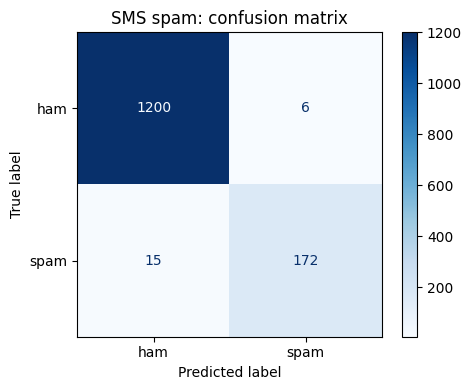

In [4]:
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(5.0, 4.0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
plt.title("SMS spam: confusion matrix")
plt.tight_layout()
plt.show()

In [5]:
# Inspect words most associated with spam vs ham.
feature_names = np.array(vectorizer.get_feature_names_out())
class_to_idx = {c: i for i, c in enumerate(model.classes_)}

spam_idx = class_to_idx["spam"]
ham_idx = class_to_idx["ham"]

log_odds = model.feature_log_prob_[spam_idx] - model.feature_log_prob_[ham_idx]
top_spam = feature_names[np.argsort(log_odds)[-15:][::-1]]
top_ham = feature_names[np.argsort(log_odds)[:15]]

print("Top words for spam:")
print(", ".join(top_spam))

print("\nTop words for ham:")
print(", ".join(top_ham))

Top words for spam:
claim, prize, 150p, tone, 500, 18, guaranteed, cs, 1000, awarded, uk, 150ppm, www, collection, award

Top words for ham:
gt, lt, lor, da, later, ì_, ll, doing, say, really, ask, amp, home, morning, said


## 2. Interpretation

- We used a real SMS dataset in CSV format.
- Pipeline: raw text -> token counts -> Naive Bayes -> spam prediction.
- Naive Bayes is simple, fast, and often a strong baseline for text classification.